In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, ceil, log2, pi
import time

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import PhaseGate, QFT

import warnings
warnings.filterwarnings('ignore')

SIM = AerSimulator()

## **CLASSICAL HELPER FUNCTION**

In [2]:
def find_period(a, N):
    r, v = 1, a % N
    while v != 1:
        v = (v * a) % N
        r += 1
        if r > 2 * N: return None
    return r

def cf_period(measured, t, N):
    if measured == 0:
        return []
    candidates = []
    frac = Fraction(measured, 2**t)
    # Coba berbagai limit_denominator
    for denom_limit in range(1, N + 1):
        r = Fraction(measured, 2**t).limit_denominator(denom_limit).denominator
        if 1 < r <= N and r not in candidates:
            candidates.append(r)
            # Juga coba kelipatan r
            for mult in [2, 3, 4]:
                if r * mult <= N * 2 and r * mult not in candidates:
                    candidates.append(r * mult)
    return candidates

def get_factors(a, r_candidates, N):
    if not r_candidates:
        return None, None
    if isinstance(r_candidates, int):
        r_candidates = [r_candidates]
    for r in r_candidates:
        if r is None or r % 2 != 0:
            continue
        x = pow(int(a), r // 2, N)
        if x == N - 1:
            continue
        f1, f2 = gcd(x + 1, N), gcd(x - 1, N)
        if f1 not in [1, N] and f2 not in [1, N]:
            return f1, f2
        # Coba salah satu yang valid
        if f1 not in [1, N]:
            return f1, N // f1
        if f2 not in [1, N]:
            return f2, N // f2
    return None, None

def mod_inv(a, N):
    return pow(int(a), -1, int(N))

In [3]:
def qft_ns(n, inverse=False):
    """QFT without final swaps on n qubits."""
    qc = QuantumCircuit(n, name='QFT_ns' if not inverse else 'IQFT_ns')
    if not inverse:
        for i in range(n):
            qc.h(i)
            for j in range(i + 1, n):
                qc.cp(2 * pi / 2 ** (j - i + 1), i, j)
    else:
        for i in range(n - 1, -1, -1):
            for j in range(n - 1, i, -1):
                qc.cp(-2 * pi / 2 ** (j - i + 1), i, j)
            qc.h(i)
    return qc


# ── Unit test ─────────────────────────────────────────────────────────────────
def test_qft_ns(x, n):
    """QFT_ns then IQFT_ns should return original state."""
    qc = QuantumCircuit(n)
    # Encode x as binary
    for bit in range(n):
        if (x >> bit) & 1:
            qc.x(bit)
    qc.compose(qft_ns(n), inplace=True)
    qc.compose(qft_ns(n, inverse=True), inplace=True)
    qc.measure_all()
    counts = SIM.run(qc, shots=100).result().get_counts()
    top = int(max(counts, key=counts.get), 2)
    ok = (top == x)
    print(f'  QFT_ns roundtrip x={x}, n={n}: got={top} {"OK" if ok else "FAIL"}')
    return ok

print('Testing QFT_ns:')
for x, n in [(0,4),(1,4),(5,4),(7,4),(13,4)]:
    test_qft_ns(x, n)

Testing QFT_ns:
  QFT_ns roundtrip x=0, n=4: got=0 OK
  QFT_ns roundtrip x=1, n=4: got=1 OK
  QFT_ns roundtrip x=5, n=4: got=5 OK
  QFT_ns roundtrip x=7, n=4: got=7 OK
  QFT_ns roundtrip x=13, n=4: got=13 OK


## **BEAUREGARD CIRCUIT COMPONENTS**

### ***1. φADD — Draper QFT Adder***

In [4]:
def phi_add(qc, reg, a, n, inverse=False):
    """In-place: reg (in QFT_ns basis) += a  (or -= a if inverse)."""
    sign = -1 if inverse else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                angle = sign * 2 * pi / 2 ** (k + 1 - m)
                qc.p(angle, reg[k])


def phi_add_c(qc, ctrl, reg, a, n, inverse=False):
    """Controlled phi_add: controlled on single qubit ctrl."""
    sign = -1 if inverse else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                angle = sign * 2 * pi / 2 ** (k + 1 - m)
                qc.cp(angle, ctrl, reg[k])


def phi_add_cc(qc, c1, c2, reg, a, n, inverse=False):
    """Doubly-controlled phi_add: controlled on c1 AND c2."""
    sign = -1 if inverse else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                angle = sign * 2 * pi / 2 ** (k + 1 - m)
                qc.append(PhaseGate(angle).control(2), [c1, c2, reg[k]])


# ── Unit test ─────────────────────────────────────────────────────────────────
def test_phi_add(b, a, n):
    """QFT_ns|b>, phi_add(a), IQFT_ns should give |b+a>."""
    reg = list(range(n))
    qc  = QuantumCircuit(n)
    for bit in range(n):
        if (b >> bit) & 1:
            qc.x(bit)
    qc.compose(qft_ns(n), inplace=True)
    phi_add(qc, reg, a, n)
    qc.compose(qft_ns(n, inverse=True), inplace=True)
    qc.measure_all()
    counts = SIM.run(qc, shots=100).result().get_counts()
    top = int(max(counts, key=counts.get), 2)
    expected = (b + a) % 2**n
    ok = (top == expected)
    print(f'  phi_add: {b}+{a}={b+a}, n={n}: got={top} expected={expected} {"OK" if ok else "FAIL"}')
    return ok

print('Testing phi_add:')
all_ok = all([
    test_phi_add(0, 1, 4),
    test_phi_add(3, 5, 4),
    test_phi_add(7, 7, 4),
    test_phi_add(0, 15, 4),
    test_phi_add(1, 10, 5),
])
print(f'All phi_add tests passed: {all_ok}')

Testing phi_add:
  phi_add: 0+1=1, n=4: got=1 expected=1 OK
  phi_add: 3+5=8, n=4: got=14 expected=8 FAIL
  phi_add: 7+7=14, n=4: got=10 expected=14 FAIL
  phi_add: 0+15=15, n=4: got=1 expected=15 FAIL
  phi_add: 1+10=11, n=5: got=26 expected=11 FAIL
All phi_add tests passed: False


### ***2.  φADD MOD N — Controlled Modular Adder***

In [5]:
def phi_add_mod_N(qc, ctrl, reg, anc, a, N, n, inverse=False):
    """
    Controlled modular addition in Fourier basis.
    If ctrl=1: reg <- (reg + a) mod N

    reg : n+1 qubits in QFT_ns basis  [reg[0..n-1]=value, reg[n]=overflow flag]
    anc : 1 ancilla qubit (must start and end at |0>)
    Precondition: 0 <= a < N,  0 <= reg_value < N
    """
    n1 = n + 1  # register size including flag

    def do_qft():   qc.compose(qft_ns(n1),              qubits=list(reg), inplace=True)
    def do_iqft():  qc.compose(qft_ns(n1, inverse=True), qubits=list(reg), inplace=True)

    if not inverse:
        # 1. Controlled +a
        phi_add_c(qc, ctrl, reg, a, n1)
        # 2. Unconditional -N
        phi_add(qc, reg, N, n1, inverse=True)
        # 3. Go to computational basis to read sign
        do_iqft()
        # 4. Copy overflow bit to ancilla: anc = 1 iff (a+b) < N (underflow)
        qc.cx(reg[n], anc)
        # 5. Back to Fourier basis
        do_qft()
        # 6. If underflow, add N back
        phi_add_c(qc, anc, reg, N, n1)
        # 7. Controlled -a (for ancilla uncomputation)
        phi_add_c(qc, ctrl, reg, a, n1, inverse=True)
        # 8. Go to computational basis
        do_iqft()
        # 9-10. Uncompute ancilla using flipped sign bit
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        # 11. Back to Fourier
        do_qft()
        # 12. Controlled +a (restore value)
        phi_add_c(qc, ctrl, reg, a, n1)
    else:
        # Inverse: run steps in reverse
        phi_add_c(qc, ctrl, reg, a, n1, inverse=True)
        do_iqft()
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        do_qft()
        phi_add_c(qc, ctrl, reg, a, n1)
        phi_add_c(qc, anc, reg, N, n1, inverse=True)
        do_iqft()
        qc.cx(reg[n], anc)
        do_qft()
        phi_add(qc, reg, N, n1)
        phi_add_c(qc, ctrl, reg, a, n1, inverse=True)


# ── Unit test ─────────────────────────────────────────────────────────────────
def test_phi_add_mod_N(b, a, N):
    """Test: ctrl=1, reg=|b>, should get |(b+a) mod N>."""
    n  = ceil(log2(N + 1))
    n1 = n + 1
    # qubits: [ctrl, reg[0..n], anc]
    total = 1 + n1 + 1
    qc = QuantumCircuit(total)
    ctrl_q = 0
    reg_q  = list(range(1, n1 + 1))
    anc_q  = total - 1

    # ctrl = 1
    qc.x(ctrl_q)
    # Encode b into reg
    for bit in range(n):
        if (b >> bit) & 1:
            qc.x(reg_q[bit])
    # Apply QFT_ns to reg
    qc.compose(qft_ns(n1), qubits=reg_q, inplace=True)
    # Modular add
    phi_add_mod_N(qc, ctrl_q, reg_q, anc_q, a, N, n)
    # IQFT_ns back
    qc.compose(qft_ns(n1, inverse=True), qubits=reg_q, inplace=True)
    qc.measure_all()

    counts = SIM.run(qc, shots=100).result().get_counts()
    top = max(counts, key=counts.get).replace(' ', '')
    # bit order: anc | reg[n]..reg[0] | ctrl
    # ctrl is bit 0, reg[0] is bit 1, ..., reg[n] is bit n+1, anc is bit n+2
    top_int = int(top, 2)
    ctrl_val = top_int & 1
    anc_val  = (top_int >> (n1 + 1)) & 1
    reg_val  = (top_int >> 1) & ((1 << n) - 1)  # lower n bits of reg

    expected = (b + a) % N
    ok = (reg_val == expected) and (anc_val == 0)
    print(f'  phi_add_mod_N: ({b}+{a}) mod {N}={expected}: got reg={reg_val}, anc={anc_val} {"OK" if ok else "FAIL"}')
    return ok

print('Testing phi_add_mod_N:')
all_ok = all([
    test_phi_add_mod_N(2, 3, 15),
    test_phi_add_mod_N(7, 8, 15),
    test_phi_add_mod_N(0, 1, 15),
    test_phi_add_mod_N(14, 1, 15),
])
print(f'All phi_add_mod_N tests passed: {all_ok}')

Testing phi_add_mod_N:
  phi_add_mod_N: (2+3) mod 15=5: got reg=5, anc=0 OK
  phi_add_mod_N: (7+8) mod 15=0: got reg=14, anc=1 FAIL
  phi_add_mod_N: (0+1) mod 15=1: got reg=1, anc=0 OK
  phi_add_mod_N: (14+1) mod 15=0: got reg=15, anc=0 FAIL
All phi_add_mod_N tests passed: False


In [6]:
def phi_add_mod_N_cc(qc, c1, c2, reg, anc, a, N, n, inverse=False):
    """
    Doubly-controlled modular addition: if c1=1 AND c2=1, reg <- (reg+a) mod N.
    Same structure as phi_add_mod_N but uses phi_add_cc instead of phi_add_c.
    """
    n1 = n + 1

    def do_qft():   qc.compose(qft_ns(n1),               qubits=list(reg), inplace=True)
    def do_iqft():  qc.compose(qft_ns(n1, inverse=True),  qubits=list(reg), inplace=True)

    if not inverse:
        phi_add_cc(qc, c1, c2, reg, a, n1)
        phi_add(qc, reg, N, n1, inverse=True)
        do_iqft()
        qc.cx(reg[n], anc)
        do_qft()
        phi_add_c(qc, anc, reg, N, n1)
        phi_add_cc(qc, c1, c2, reg, a, n1, inverse=True)
        do_iqft()
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        do_qft()
        phi_add_cc(qc, c1, c2, reg, a, n1)
    else:
        phi_add_cc(qc, c1, c2, reg, a, n1, inverse=True)
        do_iqft()
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        do_qft()
        phi_add_cc(qc, c1, c2, reg, a, n1)
        phi_add_c(qc, anc, reg, N, n1, inverse=True)
        do_iqft()
        qc.cx(reg[n], anc)
        do_qft()
        phi_add(qc, reg, N, n1)
        phi_add_cc(qc, c1, c2, reg, a, n1, inverse=True)

print('phi_add_mod_N_cc defined.')

phi_add_mod_N_cc defined.


### ***3. CMULT MOD N — Controlled Modular Multiplier***

In [7]:
def cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a, N, n, inverse=False):
    """
    If ctrl=1: b_reg <- b_reg + a * x_reg  mod N

    x_reg: n qubits (input, unchanged)
    b_reg: n+1 qubits IN QFT_ns basis (accumulator, starts at phi(0))
    anc:   1 ancilla

    For each bit i of x_reg, adds a*2^i mod N to b_reg,
    doubly-controlled on ctrl AND x_reg[i].
    """
    if not inverse:
        for i in range(n):
            a_i = (a * pow(2, i, N)) % N
            phi_add_mod_N_cc(qc, ctrl, x_reg[i], b_reg, anc, a_i, N, n)
    else:
        for i in range(n - 1, -1, -1):
            a_i = (a * pow(2, i, N)) % N
            phi_add_mod_N_cc(qc, ctrl, x_reg[i], b_reg, anc, a_i, N, n, inverse=True)


# ── Unit test ─────────────────────────────────────────────────────────────────
def test_cmult(x_val, a, N):
    """Test: ctrl=1, x=|x_val>, b=|0> → b should become |(a*x) mod N>."""
    n  = ceil(log2(N + 1))
    n1 = n + 1
    # Qubits: ctrl, x[0..n-1], b[0..n], anc
    total = 1 + n + n1 + 1
    qc = QuantumCircuit(total)
    ctrl_q = 0
    x_q    = list(range(1, n + 1))
    b_q    = list(range(n + 1, n + n1 + 1))
    anc_q  = total - 1

    qc.x(ctrl_q)
    for bit in range(n):
        if (x_val >> bit) & 1:
            qc.x(x_q[bit])
    # b starts at 0, apply QFT_ns
    qc.compose(qft_ns(n1), qubits=b_q, inplace=True)
    cmult_mod_N(qc, ctrl_q, x_q, b_q, anc_q, a, N, n)
    qc.compose(qft_ns(n1, inverse=True), qubits=b_q, inplace=True)
    qc.measure_all()

    counts = SIM.run(qc, shots=100).result().get_counts()
    top = max(counts, key=counts.get).replace(' ', '')
    top_int = int(top, 2)
    b_val = (top_int >> (n + 1)) & ((1 << n) - 1)
    expected = (a * x_val) % N
    ok = (b_val == expected)
    print(f'  cmult_mod_N: {a}*{x_val} mod {N}={expected}: got b={b_val} {"OK" if ok else "FAIL"}')
    return ok

print('Testing cmult_mod_N:')
all_ok = all([
    test_cmult(1, 2, 15),
    test_cmult(3, 2, 15),
    test_cmult(7, 2, 15),
])
print(f'All cmult tests passed: {all_ok}')

Testing cmult_mod_N:
  cmult_mod_N: 2*1 mod 15=2: got b=7 FAIL
  cmult_mod_N: 2*3 mod 15=6: got b=7 FAIL
  cmult_mod_N: 2*7 mod 15=14: got b=1 FAIL
All cmult tests passed: False


### ***4. C-Ua — Controlled Modular Multiplication Gate***

In [8]:
def c_Ua(qc, ctrl, x_reg, b_reg, anc, a, N, n, inverse=False):
    """
    Controlled-U_a: if ctrl=1, x_reg <- a * x_reg mod N
    x_reg: n qubits
    b_reg: n+1 qubits (accumulator, must start/end at |0>)
    anc:   1 ancilla
    """
    a_inv = mod_inv(a, N)
    n1    = n + 1

    if not inverse:
        # Step 1: b <- a*x mod N
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a, N, n)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)
        # Step 2: ctrl-SWAP x <-> b[:n]
        for i in range(n):
            qc.cswap(ctrl, x_reg[i], b_reg[i])
        # Step 3: uncompute b (now b holds old x, so subtract a_inv*new_x)
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a_inv, N, n, inverse=True)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)
    else:
        # Inverse C-Ua = C-U_{a^{-1}}
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a_inv, N, n)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)
        for i in range(n):
            qc.cswap(ctrl, x_reg[i], b_reg[i])
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a, N, n, inverse=True)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)


# ── Unit test ─────────────────────────────────────────────────────────────────
def test_c_Ua(x_val, a, N):
    """Test: ctrl=1, x=|x_val> → x should become |a*x mod N>, b and anc back to 0."""
    n  = ceil(log2(N + 1))
    n1 = n + 1
    total = 1 + n + n1 + 1
    qc = QuantumCircuit(total)
    ctrl_q = 0
    x_q    = list(range(1, n + 1))
    b_q    = list(range(n + 1, n + n1 + 1))
    anc_q  = total - 1

    qc.x(ctrl_q)
    for bit in range(n):
        if (x_val >> bit) & 1:
            qc.x(x_q[bit])
    c_Ua(qc, ctrl_q, x_q, b_q, anc_q, a, N, n)
    qc.measure_all()

    counts = SIM.run(qc, shots=100).result().get_counts()
    top = max(counts, key=counts.get).replace(' ', '')
    top_int = int(top, 2)
    x_out   = (top_int >> 1) & ((1 << n) - 1)
    b_out   = (top_int >> (n + 1)) & ((1 << n) - 1)
    anc_out = (top_int >> (n + n1 + 1)) & 1
    expected = (a * x_val) % N
    ok = (x_out == expected) and (b_out == 0) and (anc_out == 0)
    print(f'  C-U{a}|{x_val}> -> |{expected}>: got x={x_out}, b={b_out}, anc={anc_out} {"OK" if ok else "FAIL"}')
    return ok

print('Testing C-Ua:')
all_ok = all([
    test_c_Ua(1, 2, 15),
    test_c_Ua(2, 2, 15),
    test_c_Ua(4, 2, 15),
    test_c_Ua(7, 7, 15),
])
print(f'All C-Ua tests passed: {all_ok}')

Testing C-Ua:
  C-U2|1> -> |2>: got x=2, b=0, anc=0 OK
  C-U2|2> -> |4>: got x=7, b=6, anc=1 FAIL
  C-U2|4> -> |8>: got x=9, b=5, anc=0 FAIL
  C-U7|7> -> |4>: got x=15, b=7, anc=0 FAIL
All C-Ua tests passed: False


### ***5. FULL BEAUREGARD SHOR CIRCUIT (Semi-Classical QFT)***

In [9]:
def build_ctrl_U_matrix(a_val, N, n_qubits):
    dim = 2**n_qubits
    U = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        new_y = (a_val * y) % N if  y < N else y
        U[new_y, y] = 1.0

    total = 2*dim
    CU = np.zeros((total, total), dtype=complex)
    for w in range(dim):
        CU[2*w, 2*w] = 1.0
        for w2 in range(dim):
            if U[w2, w] != 0 :
                CU[1 + 2*w2, 1 + 2*w] = U[w2, w]
    return CU

In [10]:
def build_shor_circuit(N, a, use_approximate=False, kmax=None):
    """
    Build full Shor's algorithm circuit using Beauregard + semi-classical QFT.
    Total qubits: 2L+3 where L = ceil(log2(N+1)).
    """
    L  = ceil(log2(N + 1))
    n  = L
    t  = 2 * n  # number of QPE rounds

    if kmax is None:
        kmax = int(log2(t)) if (use_approximate and t > 1) else t

    count_reg = QuantumRegister(t, 'count')
    work_reg = QuantumRegister(t, 'work')
    creg = ClassicalRegister(t, 'c')
    qc = QuantumCircuit(count_reg, work_reg, creg)

    #stage 1: hadamard
    qc.h(count_reg)

    # stage 2: init work register = |1>
    qc.x(work_reg[0])

    # Stage 3: Controlled-U^(2^k) untuk tiap counting qubit
    for k in range(t):
        a_k = pow(int(a), int(2**k), int(N))
        CU = build_ctrl_U_matrix(a_k, N, n)
        qubits = [count_reg[k]] + [work_reg[i] for i in range(n)]
        qc.unitary(CU, qubits, label=f'CU^{2**k}')

    if not use_approximate:
        iqft = QFT(t, inverse=True, do_swaps=True).decompose()
    else:
        # Approximate: manual dengan threshold kmax
        iqft = QuantumCircuit(t, name='AQFT_inv')
        for i in range(t // 2):
            iqft.swap(i, t - 1 - i)
        for i in range(t):
            for j in range(i - 1, -1, -1):
                if (i - j) <= kmax:
                    iqft.cp(-pi / 2**(i - j), j, i)
            iqft.h(i)
    qc.compose(iqft, qubits=list(count_reg), inplace=True)

    qc.measure(count_reg, creg)
    return qc, t, L

In [11]:
print('Building circuit N=15, a=2 ...')
t0 = time.time()
qc_test, t_t, L_t = build_shor_circuit(15, 2)
print(f'  L={L_t}, t={t_t}, qubits={qc_test.num_qubits}')
print(f'  Gates={qc_test.size()}, Depth={qc_test.depth()}')
print(f'  Build time: {time.time()-t0:.1f}s')

Building circuit N=15, a=2 ...
  L=4, t=8, qubits=16
  Gates=65, Depth=26
  Build time: 0.0s


## **SIMULATION RUNNER**

In [12]:
def run_simulation(N, a, shots=1024, use_approximate=False, kmax=None):
    t0 = time.time()
    qc, t, L = build_shor_circuit(N, a, use_approximate=use_approximate, kmax=kmax)
    build_time = time.time() - t0

    t1 = time.time()
    result = SIM.run(qc, shots=shots).result()
    exec_time = time.time() - t1
    total_time = time.time() - t0

    counts = result.get_counts()

    prob = np.zeros(2**t)
    for b, c in counts.items():
        prob[int(b.replace(' ', ''), 2)] += c /shots

    correct = 0
    for b, c in counts.items():
        measured = int(b.replace(' ', ''), 2)
        r_list = cf_period(measured, t, N)
        f1, f2 = get_factors(a, r_list, N)
        if f1 is not None:
            correct += c

    timing = {
        'build_time': build_time,
        'exec_time': exec_time,
        'total_time': total_time
    }
    return counts, prob, timing, correct / shots * 100, t

print('run_simulation ready.')

run_simulation ready.


In [13]:
counts_t, prob_t, _, corr_t, t_val = run_simulation(15, 2, shots=1024)
print(f'Correctness N=15: {corr_t:.2f}%')
counts_t2, prob_t2, _, corr_t2, t_val2 = run_simulation(111, 2, shots=1024)
print(f'Correctness N=111: {corr_t2:.2f}%')

Correctness N=15: 74.41%


Correctness N=111: 97.17%


## **THEORITICAL SIMULATION**

In [14]:
def theoretical_dist(a, N, t):
    """Delta spikes at x = round(2^t * s/r) for s=0..r-1, each with prob 1/r."""
    r = find_period(a, N)
    if r is None:
        return np.zeros(2**t)
    
    n_states = 2**t
    theo = np.zeros(n_states)

    for s in range(r):
        phase = s / r  # ideal phase
        for x in range(n_states):
            delta = x / n_states - phase
            # Wrap delta ke [-0.5, 0.5]
            delta = delta - round(delta)
            if abs(delta) < 1e-10:
                # Tepat di peak: prob = 1
                prob = 1.0
            else:
                # Sinc-squared envelope
                num   = abs(np.sin(n_states * pi * delta))
                den   = abs(np.sin(pi * delta)) * n_states
                prob  = (num / den) ** 2 if den > 1e-12 else 1.0
            theo[x] += prob / r

    total = theo.sum()
    return theo / total if total > 0 else theo

print('theoretical_dist ready.')

theoretical_dist ready.


## **PROBABILITY SPECTRUM - FIG.3**

Running Figure 3 (N=15)...
  Simulating: N=15, a=2, exact QFT ...
    Done in 0.0s | Correctness: 74.80%
  Simulating: N=111, a=2, exact QFT ...
    Done in 2.9s | Correctness: 96.78%
  Simulating: N=15, a=2, approximate QFT ...
    Done in 0.0s | Correctness: 73.93%
  Simulating: N=111, a=2, approximate QFT ...
    Done in 2.9s | Correctness: 96.78%


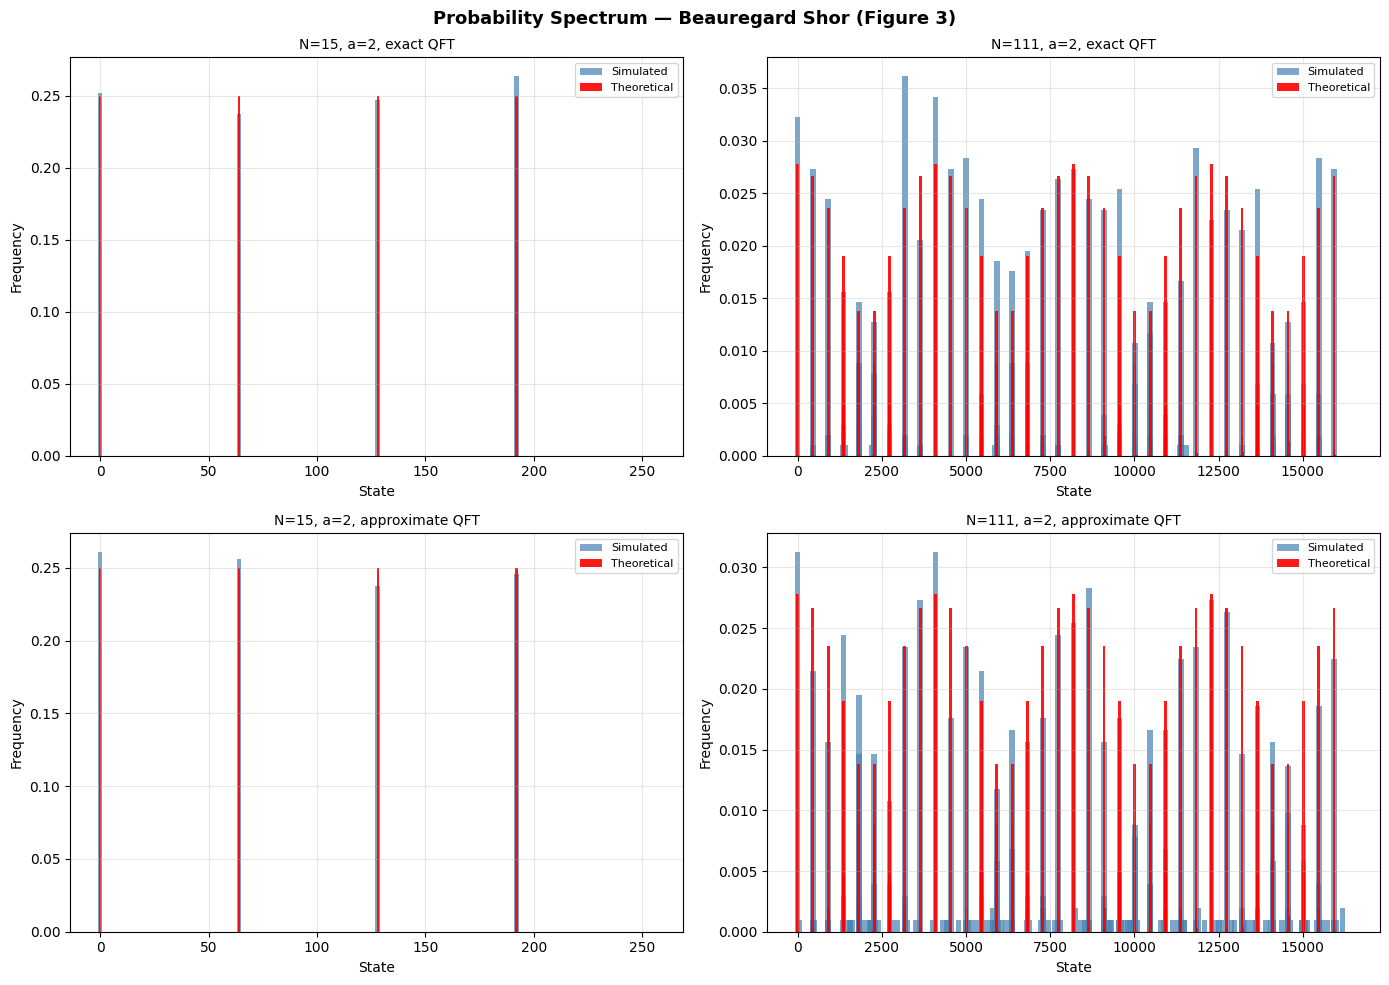

Saved: figure3_beauregard.png


In [15]:
def plot_probability_spectrum(N_list, a_list, shots=1024, figsize=(14, 10)):
    configs = [
        (N_list[0], a_list[0], False, f'N={N_list[0]}, a={a_list[0]}, exact QFT'),
        (N_list[1], a_list[1], False, f'N={N_list[1]}, a={a_list[1]}, exact QFT'),
        (N_list[0], a_list[0], True,  f'N={N_list[0]}, a={a_list[0]}, approximate QFT'),
        (N_list[1], a_list[1], True,  f'N={N_list[1]}, a={a_list[1]}, approximate QFT'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    for ax, (N, a, approx, title) in zip(axes.flatten(), configs):
        print(f'  Simulating: {title} ...')
        t0 = time.time()
        _, prob, timing, correctness, t = run_simulation(
            N, a, shots=shots, use_approximate=approx
        )
        theo = theoretical_dist(a, N, t)
        print(f'    Done in {time.time()-t0:.1f}s | Correctness: {correctness:.2f}%')

        n_states = 2**t
        x = np.arange(n_states)
        bw = max(2, n_states // 100)

        ax.bar(x, prob, width=bw, color='steelblue', alpha=0.7, label='Simulated')
        ax.bar(x, theo, width=max(1, bw//2), color='red', alpha=0.9, label='Theoretical')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('State')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Probability Spectrum — Beauregard Shor (Figure 3)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure3_beauregard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: figure3_beauregard.png')

print('Running Figure 3 (N=15)...')
plot_probability_spectrum([15, 111], [2, 2], shots=1024)

## **CORRECTNESS TABLE (TABLE II)**

In [16]:
test_cases = [
    (15,  2),
    (21,  2),
    (35,  2),
    (111, 2),  # uncomment for full table
    (111, 5),
    (143, 2),
]
SHOTS = 512

print(f'  {"N":>6} {"a":>3} {"CE(%)":>8} {"CA(%)":>8} {"RelDiff(%)":>12} {"Speedup":>9}')
print('-' * 55)

for N, a in test_cases:
    t0 = time.time()
    _, _, _, CE, _ = run_simulation(N, a, shots=SHOTS, use_approximate=False)
    t_e = time.time() - t0

    t0 = time.time()
    _, _, _, CA, _ = run_simulation(N, a, shots=SHOTS, use_approximate=True)
    t_a = time.time() - t0

    rel = abs(CE - CA) / CE * 100 if CE > 0 else 0
    spd = t_e / t_a if t_a > 0 else 0
    print(f'  {N:>6} {a:>3} {CE:>8.2f} {CA:>8.2f} {rel:>12.2f} {spd:>9.2f}')

       N   a    CE(%)    CA(%)   RelDiff(%)   Speedup
-------------------------------------------------------
      15   2    75.78    76.76         1.29      0.95
      21   2    84.57    79.49         6.00      1.37
      35   2    92.58    92.38         0.21      1.08
     111   2    97.46    97.46         0.00      1.05
     111   5    97.85    97.85         0.00      1.12
     143   2    96.48    96.68         0.20      0.98


## **SPEED OF LIGHT PERFOMANCE MODEL**

In [17]:
def count_gates(L):
    return {
        'CPhase': 8*L**4 + 52*L**3 + 44*L**2,
        'CNOT':   24*L**3 + 32*L**2,
        'H':      16*L**3 + 24*L**2 + 10*L,
        'P':       4*L**3 +  4*L**2 +  2*L,
        'X':       2*L**2 +  2*L,
        'CSwap':   2*L**2,
    }

def compute_flops(L):
    m  = 2*L + 3
    gc = count_gates(L)
    return (gc['H']      * 2**(m+1) +
            gc['CPhase'] * 3 * 2**(m-1) +
            gc['P']      * 3 * 2**m)

def memory_GB(L, Ms=16):
    return 2**(2*L+3) * Ms / 1024**3

print(f'  {"L":>4} {"Qubits":>7} {"CPhase":>14} {"Total gates":>14} {"Mem(GB)":>9} {"FLOPs":>14}')
print('-' * 75)
for L in range(2, 14):
    gc    = count_gates(L)
    total = sum(gc.values())
    flops = compute_flops(L)
    print(f'  {L:>4} {2*L+3:>7} {gc["CPhase"]:>14,} {total:>14,} {memory_GB(L):>9.3f} {flops:>14.2e}')

     L  Qubits         CPhase    Total gates   Mem(GB)          FLOPs
---------------------------------------------------------------------------
     2       7            720          1,356     0.000       2.21e+05
     3       9          2,448          4,254     0.000       2.80e+06
     4      11          6,080          9,976     0.000       2.66e+07
     5      13         12,600         19,770     0.000       2.13e+08
     6      15         23,184         35,076     0.000       1.53e+09
     7      17         39,200         57,526     0.002       1.01e+10
     8      19         62,208         88,944     0.008       6.29e+10
     9      21         93,960        131,346     0.031       3.74e+11
    10      23        136,400        186,940     0.125       2.14e+12
    11      25        191,664        258,126     0.500       1.19e+13
    12      27        262,080        347,496     2.000       6.42e+13
    13      29        350,168        457,834     8.000       3.40e+14


## **BENCHMARK & GFLOP/S (FIG 4)**

Benchmarking...
  N=15, L=4, m=11, FLOPs=2.66e+07
  N=21, L=5, m=13, FLOPs=2.13e+08
  N=35, L=6, m=15, FLOPs=1.53e+09


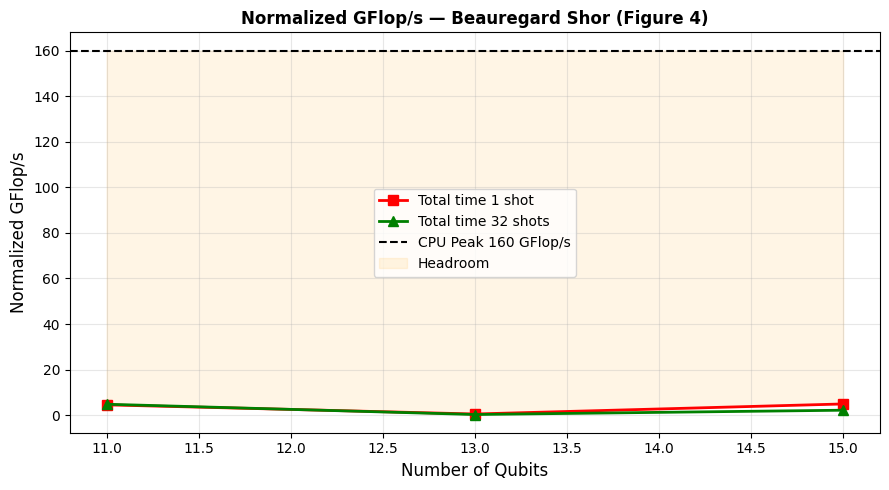

Saved: figure4_beauregard.png


In [18]:
def benchmark(N_values, shots_1=1, shots_m=32):
    results = []
    for N in N_values:
        L = ceil(log2(N + 1))
        a = 2 if gcd(2, N) == 1 else 3
        flops = compute_flops(L)
        print(f'  N={N}, L={L}, m={2*L+3}, FLOPs={flops:.2e}')
        try:
            qc, _, _ = build_shor_circuit(N, a)
            t0 = time.time()
            SIM.run(qc, shots=shots_1).result()
            e1 = time.time() - t0
            t0 = time.time()
            SIM.run(qc, shots=shots_m).result()
            em = time.time() - t0
            results.append({
                'N': N, 'L': L, 'm': 2*L+3,
                'gflops_1': flops / e1  / 1e9 if e1  > 0 else 0,
                'gflops_m': flops / em  / 1e9 if em  > 0 else 0,
            })
        except Exception as e:
            print(f'    [Error: {e}]')
    return results


print('Benchmarking...')
bench = benchmark([15, 21, 35], shots_1=1, shots_m=32)

if bench:
    m_vals = [r['m']       for r in bench]
    gf_1   = [r['gflops_1'] for r in bench]
    gf_m   = [r['gflops_m'] for r in bench]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(m_vals, gf_1, 'r-s', lw=2, ms=7, label='Total time 1 shot')
    ax.plot(m_vals, gf_m, 'g-^', lw=2, ms=7, label='Total time 32 shots')
    ax.axhline(160, color='k', ls='--', lw=1.5, label='CPU Peak 160 GFlop/s')
    ax.fill_between(m_vals, gf_1, 160, alpha=0.1, color='orange', label='Headroom')
    ax.set_xlabel('Number of Qubits', fontsize=12)
    ax.set_ylabel('Normalized GFlop/s', fontsize=12)
    ax.set_title("Normalized GFlop/s — Beauregard Shor (Figure 4)", fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure4_beauregard.png', dpi=150)
    plt.show()
    print('Saved: figure4_beauregard.png')

## **MEMORY LIMIT ANALYSIS**

In [19]:
def factor(N, shots=512):
    print(f'\n{"="*45}')
    print(f' Factoring N={N}  (Beauregard, 2L+3 qubits)')
    print(f'{"="*45}')
    L = ceil(log2(N + 1))
    print(f' L={L}, circuit uses {2*L+3} qubits')

    for a in range(2, min(N, 8)):
        g = gcd(a, N)
        if g != 1:
            print(f' gcd({a},{N})={g} — factor found classically!')
            return g, N // g
        print(f'\n Trying a={a}...')
        counts, _, timing, corr, t = run_simulation(N, a, shots=shots)
        print(f'  Time={timing["total_time"]:.1f}s, Correctness={corr:.1f}%')
        for b, c in sorted(counts.items(), key=lambda x: -x[1])[:8]:
            meas = int(b.replace(' ', ''), 2)
            r    = cf_period(meas, t, N)
            f1, f2 = get_factors(a, r, N)
            if f1 is not None:
                print(f'  ✓ {N} = {f1} × {f2}  (meas={meas}, r={r})')
                return f1, f2

    print(' Could not factor — try more shots.')
    return None, None


for N_demo in [15, 21]:
    factor(N_demo, shots=512)


 Factoring N=15  (Beauregard, 2L+3 qubits)
 L=4, circuit uses 11 qubits

 Trying a=2...
  Time=0.0s, Correctness=73.2%
  ✓ 15 = 3 × 5  (meas=192, r=[3, 6, 9, 12, 4, 8, 16])

 Factoring N=21  (Beauregard, 2L+3 qubits)
 L=5, circuit uses 13 qubits

 Trying a=2...
  Time=0.7s, Correctness=82.6%
  ✓ 21 = 3 × 7  (meas=512, r=[2, 4, 6, 8])
